Provenance verified. Dataset version: a1-2026-09-v1

--- Data Quality Audit Table ---
                             issue  affected_records                          example_record_ids                                               action                                               reason
              Exact duplicate rows                 3 Multiple duplicate instances across exports                          Drop exact duplicate copies                       Redundant data export artifact
              Superceded revisions                10             UCI-01104-r0 vs revised records    Retain record with highest revision per timestamp Contract rule: later revision replaces earlier entry
Mixed unit representations (mg/m3)               321                                UCI-01975-r0            Multiply valid non-negative mg/m3 by 1000                                 Standardise to ug/m3
      Missing sentinel code (-200)               422                                UCI-01872-r0 Conve

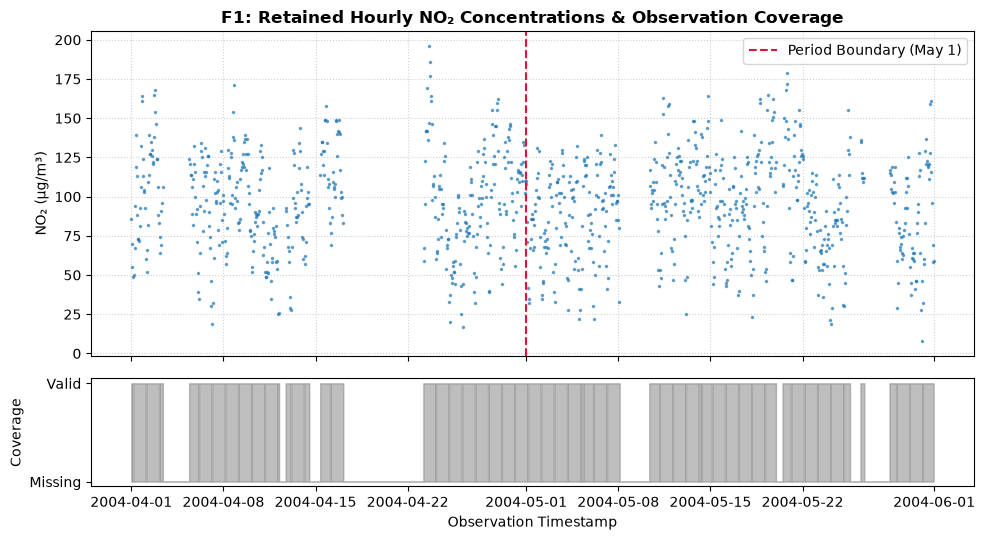

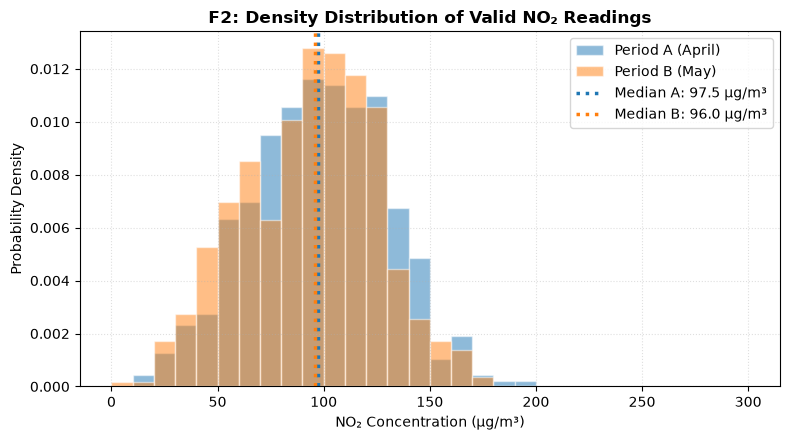

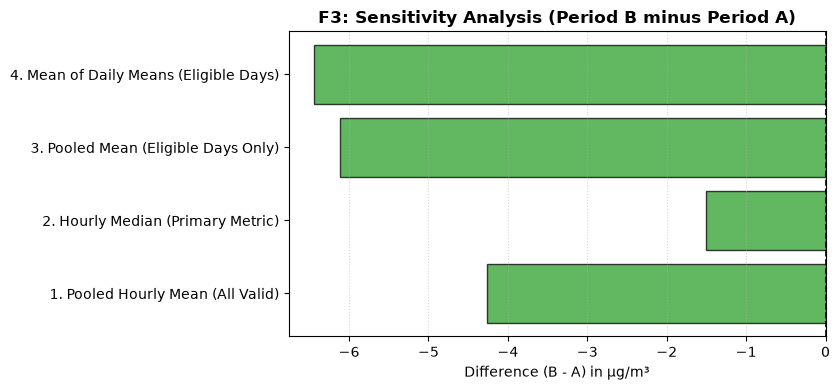


--- Running Automated Rule Verifications (T5) ---
V1 Representation Check: PASSED
V2 Revision Resolution & Shuffling Invariance Check: PASSED
V3 Weighting Arithmetic Check: PASSED

Audit pipeline complete and fully verified.


In [1]:
# Environmental Data Audit: Temporal NO2 Comparison
# ==============================================================================
# Pipeline:
# 1. Environment configuration & data integrity verification
# 2. Ingestion, deduplication, revision resolution, and unit standardisation
# 3. Exploratory audit table and period coverage extraction
# 4. Replication of uncorrected draft analyses (Draft A & Draft B)
# 5. Descriptive statistics, missing code impact, and controlled comparisons
# 6. Diagnostic visualisation generation (F1 Timeline, F2 Distributions, F3 Sensitivity)
# 7. Automated verification tests (V1 Representation, V2 Revision, V3 Weighting)
# ==============================================================================

import hashlib
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------------------------
# 1. SETUP & INTEGRITY VERIFICATION
# ------------------------------------------------------------------------------
DATA_DIR = Path("data")
REQUIRED_FILES = ["measurements.csv", "expected_hours.csv", "manifest.json"]

missing_files = [
    name for name in REQUIRED_FILES if not (DATA_DIR / name).is_file()
]
if missing_files:
  raise FileNotFoundError(
      f"Missing required data files: {missing_files}. Ensure 'data/' is"
      " present."
  )

# Verify SHA-256 checksums from manifest
manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
for name, expected_hash in manifest["files_sha256"].items():
  actual_hash = hashlib.sha256((DATA_DIR / name).read_bytes()).hexdigest()
  if actual_hash != expected_hash:
    raise ValueError(f"Integrity check failed: {name} checksum does not match.")

print("Provenance verified. Dataset version:", manifest["dataset_version"])

# Load full hourly schedule timetable
expected_hours = pd.read_csv(
    DATA_DIR / "expected_hours.csv", parse_dates=["timestamp"]
)


# ------------------------------------------------------------------------------
# 2. CORE TRANSFORMATION & DATA CLEANING FUNCTIONS
# ------------------------------------------------------------------------------
def load_measurements(path: Path) -> pd.DataFrame:
  """Loads raw sensor export CSV, parsing timestamps and revisions."""
  return pd.read_csv(
      path,
      parse_dates=["timestamp"],
      dtype={"revision": int, "source_row": int},
  )


def clean_measurements(raw: pd.DataFrame) -> pd.DataFrame:
  """Standardises raw measurements according to data dictionary rules:

  - Removes exact repeated rows.
  - Resolves revisions: retains highest revision record per unique timestamp.
  - Recognises -200 as missing BEFORE applying unit conversions.
  - Standardises valid non-negative NO2 to ug/m3 (1 mg/m3 = 1000 ug/m3).
  - Preserves variable-specific missingness (missing temp != invalid NO2).
  """
  df = raw.copy()

  # Step A: Drop exact duplicated records
  df = df.drop_duplicates()

  # Step B: Sort chronologically and by ascending revision
  df = df.sort_values(by=["timestamp", "revision"], ascending=[True, True])

  # Step C: Assert no conflicting revisions exist on tied maximum revision
  tied_conflict = df.groupby(["timestamp", "revision"]).filter(
      lambda g: len(g) > 1
  )
  if not tied_conflict.empty:
    raise ValueError(
        "Conflicting tied records detected on identical highest revision."
    )

  # Retain highest revision record per observation key
  df_retained = df.groupby("timestamp", as_index=False).last()

  # Step D: Process NO2 concentrations
  no2_numeric = df_retained["no2"].astype(float)
  # -200 indicates missingness across both measurement columns
  is_no2_valid = (no2_numeric != -200.0) & (no2_numeric >= 0.0)

  # Scale mg/m3 by 1000, keep ug/m3 as-is, set invalid/missing to NaN
  no2_std = np.where(
      is_no2_valid,
      np.where(
          df_retained["no2_unit"] == "mg/m3",
          no2_numeric * 1000.0,
          no2_numeric,
      ),
      np.nan,
  )

  # Step E: Process Temperature (valid values may be negative, -200 is missing)
  temp_numeric = df_retained["temperature_c"].astype(float)
  temp_std = np.where(temp_numeric != -200.0, temp_numeric, np.nan)

  # Assemble clean output frame
  clean_df = pd.DataFrame({
      "record_id": df_retained["record_id"],
      "timestamp": df_retained["timestamp"],
      "no2_ug_m3": no2_std,
      "temperature_c": temp_std,
  }).sort_values("timestamp").reset_index(drop=True)

  return clean_df


# Ingest and clean records
student_raw = load_measurements(DATA_DIR / "measurements.csv")
student_clean = clean_measurements(student_raw)


# ------------------------------------------------------------------------------
# 3. AUDIT METRICS & DATASET COVERAGE EXTRACTION
# ------------------------------------------------------------------------------
exact_dupes = len(student_raw) - len(student_raw.drop_duplicates())
raw_unique = student_raw.drop_duplicates()
rev_replaces = len(raw_unique) - student_clean["timestamp"].nunique()

mg_count = (student_raw["no2_unit"] == "mg/m3") & (student_raw["no2"] != -200)
no2_missing = (student_raw["no2"] == -200).sum()
temp_missing = (student_raw["temperature_c"] == -200).sum()
absent_hours = len(expected_hours) - student_clean["timestamp"].nunique()

audit_table = pd.DataFrame([
    {
        "issue": "Exact duplicate rows",
        "affected_records": int(exact_dupes),
        "example_record_ids": "Multiple duplicate instances across exports",
        "action": "Drop exact duplicate copies",
        "reason": "Redundant data export artifact",
    },
    {
        "issue": "Superceded revisions",
        "affected_records": int(rev_replaces),
        "example_record_ids": "UCI-01104-r0 vs revised records",
        "action": "Retain record with highest revision per timestamp",
        "reason": "Contract rule: later revision replaces earlier entry",
    },
    {
        "issue": "Mixed unit representations (mg/m3)",
        "affected_records": int(mg_count.sum()),
        "example_record_ids": "UCI-01975-r0",
        "action": "Multiply valid non-negative mg/m3 by 1000",
        "reason": "Standardise to ug/m3",
    },
    {
        "issue": "Missing sentinel code (-200)",
        "affected_records": int(no2_missing + temp_missing),
        "example_record_ids": "UCI-01872-r0",
        "action": "Convert -200 sentinel to NaN before numeric analysis",
        "reason": "-200 denotes instrument dropout/missingness",
    },
    {
        "issue": "Entirely absent timetable hours",
        "affected_records": int(absent_hours),
        "example_record_ids": "N/A (no export record exists)",
        "action": "Align against expected_hours timetable grid",
        "reason": "Absent records remain expected observation intervals",
    },
])

print("\n--- Data Quality Audit Table ---")
print(audit_table.to_string(index=False))

# Calculate period coverage metrics
student_clean["period"] = student_clean["timestamp"].dt.month.map(
    {4: "A", 5: "B"}
)
coverage_summary = []
for p, exp in [("A", 720), ("B", 744)]:
  sub = student_clean[student_clean["period"] == p]
  no2_valid = sub["no2_ug_m3"].notna().sum()
  temp_valid = sub["temperature_c"].notna().sum()
  coverage_summary.append({
      "period": p,
      "expected_hours": exp,
      "retained_hours": len(sub),
      "no2_valid": int(no2_valid),
      "no2_coverage_%": round(100.0 * no2_valid / exp, 2),
      "temp_valid": int(temp_valid),
      "temp_coverage_%": round(100.0 * temp_valid / exp, 2),
  })

print("\n--- Coverage Summary By Period ---")
print(pd.DataFrame(coverage_summary).to_string(index=False))


# ------------------------------------------------------------------------------
# 4. DESCRIPTIVE STATISTICS & CONTROLLED COMPARISONS
# ------------------------------------------------------------------------------
def summarise_measurements(
    clean: pd.DataFrame, timetable: pd.DataFrame
) -> pd.DataFrame:
  """Computes non-parametric and parametric statistics for NO2 and Temperature."""
  df = clean.copy()
  df["period"] = df["timestamp"].dt.month.map({4: "A", 5: "B"})

  stats = []
  for period, n_exp in [("A", 720), ("B", 744)]:
    sub = df[df["period"] == period]
    for var in ["no2_ug_m3", "temperature_c"]:
      series = sub[var].dropna()
      n_valid = len(series)
      cov_pct = 100.0 * n_valid / n_exp
      miss_pct = 100.0 - cov_pct

      # Quartiles using linear interpolation
      q1 = series.quantile(0.25, interpolation="linear")
      q3 = series.quantile(0.75, interpolation="linear")

      stats.append({
          "period": period,
          "variable": var,
          "n_expected": n_exp,
          "n_valid": n_valid,
          "coverage_percent": round(cov_pct, 2),
          "missing_percent": round(miss_pct, 2),
          "mean": round(series.mean(), 3),
          "median": round(series.median(), 3),
          "std": round(series.std(ddof=1), 3),
          "q1": round(q1, 3),
          "q3": round(q3, 3),
          "iqr": round(q3 - q1, 3),
          "min": round(series.min(), 3),
          "max": round(series.max(), 3),
      })
  return pd.DataFrame(stats)


summary_results = summarise_measurements(student_clean, expected_hours)
print("\n--- Summary Statistics (T3 Required Table) ---")
print(summary_results.to_string(index=False))

# Sensitivity & Controlled Comparison Table
# Rule: A day is eligible if at least 18 of its 24 expected hourly NO2 readings are valid
clean_calc = student_clean.copy()
clean_calc["date"] = clean_calc["timestamp"].dt.date
clean_calc["period"] = clean_calc["timestamp"].dt.month.map({4: "A", 5: "B"})

daily_metrics = (
    clean_calc.groupby(["period", "date"])["no2_ug_m3"]
    .agg(valid_count=lambda x: x.notna().sum(), daily_mean="mean")
    .reset_index()
)
eligible_days = daily_metrics[daily_metrics["valid_count"] >= 18]

# Hourly series
hours_A = clean_calc[clean_calc["period"] == "A"]["no2_ug_m3"].dropna()
hours_B = clean_calc[clean_calc["period"] == "B"]["no2_ug_m3"].dropna()

# Eligible-day subsets
elig_dates_A = set(eligible_days[eligible_days["period"] == "A"]["date"])
elig_dates_B = set(eligible_days[eligible_days["period"] == "B"]["date"])

elig_hours_A = clean_calc[
    (clean_calc["period"] == "A") & (clean_calc["date"].isin(elig_dates_A))
]["no2_ug_m3"].dropna()
elig_hours_B = clean_calc[
    (clean_calc["period"] == "B") & (clean_calc["date"].isin(elig_dates_B))
]["no2_ug_m3"].dropna()

daily_means_A = eligible_days[eligible_days["period"] == "A"]["daily_mean"]
daily_means_B = eligible_days[eligible_days["period"] == "B"]["daily_mean"]

comparison_results = pd.DataFrame([
    {
        "method": "1. Pooled Hourly Mean (All Valid)",
        "estimate_A": round(hours_A.mean(), 3),
        "estimate_B": round(hours_B.mean(), 3),
        "difference_B_minus_A": round(hours_B.mean() - hours_A.mean(), 3),
        "n_A": len(hours_A),
        "n_B": len(hours_B),
        "units": "ug/m3 (hourly count)",
    },
    {
        "method": "2. Hourly Median (Primary Metric)",
        "estimate_A": round(hours_A.median(), 3),
        "estimate_B": round(hours_B.median(), 3),
        "difference_B_minus_A": round(hours_B.median() - hours_A.median(), 3),
        "n_A": len(hours_A),
        "n_B": len(hours_B),
        "units": "ug/m3 (hourly count)",
    },
    {
        "method": "3. Pooled Mean (Eligible Days Only)",
        "estimate_A": round(elig_hours_A.mean(), 3),
        "estimate_B": round(elig_hours_B.mean(), 3),
        "difference_B_minus_A": round(
            elig_hours_B.mean() - elig_hours_A.mean(), 3
        ),
        "n_A": len(elig_hours_A),
        "n_B": len(elig_hours_B),
        "units": "ug/m3 (hourly count)",
    },
    {
        "method": "4. Mean of Daily Means (Eligible Days)",
        "estimate_A": round(daily_means_A.mean(), 3),
        "estimate_B": round(daily_means_B.mean(), 3),
        "difference_B_minus_A": round(
            daily_means_B.mean() - daily_means_A.mean(), 3
        ),
        "n_A": len(daily_means_A),
        "n_B": len(daily_means_B),
        "units": "ug/m3 (eligible day count)",
    },
])

print("\n--- Controlled Method Comparison Table ---")
print(comparison_results.to_string(index=False))


# ------------------------------------------------------------------------------
# 5. MATPLOTLIB EVIDENCE VISUALISATIONS (T4)
# ------------------------------------------------------------------------------
def make_evidence_figures(
    clean: pd.DataFrame, timetable: pd.DataFrame, comparisons: pd.DataFrame
) -> dict:
  """Produces F1 (Time and coverage), F2 (Distribution), and F3 (Sensitivity)."""
  figures = {}

  # Grid alignment for accurate time series representation
  grid = timetable.copy()
  merged = pd.merge(grid, clean, on="timestamp", how="left")

  # F1: Time & Coverage Panel
  fig1, (ax1a, ax1b) = plt.subplots(
      2, 1, figsize=(10, 5.5), sharex=True, height_ratios=[3, 1]
  )
  ax1a.plot(
      merged["timestamp"],
      merged["no2_ug_m3"],
      marker=".",
      linestyle="none",
      markersize=3,
      alpha=0.6,
      color="#1f77b4",
  )
  ax1a.axvline(
      pd.to_datetime("2004-05-01 00:00:00"),
      color="crimson",
      linestyle="--",
      label="Period Boundary (May 1)",
  )
  ax1a.set_title(
      "F1: Retained Hourly NO₂ Concentrations & Observation Coverage",
      fontsize=12,
      fontweight="bold",
  )
  ax1a.set_ylabel("NO₂ (µg/m³)")
  ax1a.legend(loc="upper right")
  ax1a.grid(True, linestyle=":", alpha=0.6)

  valid_mask = merged["no2_ug_m3"].notna().astype(int)
  ax1b.fill_between(
      merged["timestamp"], 0, valid_mask, step="mid", color="#7f7f7f", alpha=0.5
  )
  ax1b.set_xlabel("Observation Timestamp")
  ax1b.set_ylabel("Coverage")
  ax1b.set_yticks([0, 1])
  ax1b.set_yticklabels(["Missing", "Valid"])
  fig1.tight_layout()
  figures["F1"] = fig1

  # F2: Distribution Panel
  fig2, ax2 = plt.subplots(figsize=(8, 4.5))
  valid_only = clean.dropna(subset=["no2_ug_m3"]).copy()
  valid_only["period"] = valid_only["timestamp"].dt.month.map({4: "A", 5: "B"})

  bins = np.linspace(0, 300, 31)
  ax2.hist(
      valid_only[valid_only["period"] == "A"]["no2_ug_m3"],
      bins=bins,
      alpha=0.5,
      density=True,
      label="Period A (April)",
      color="#1f77b4",
      edgecolor="white",
  )
  ax2.hist(
      valid_only[valid_only["period"] == "B"]["no2_ug_m3"],
      bins=bins,
      alpha=0.5,
      density=True,
      label="Period B (May)",
      color="#ff7f0e",
      edgecolor="white",
  )

  med_A = valid_only[valid_only["period"] == "A"]["no2_ug_m3"].median()
  med_B = valid_only[valid_only["period"] == "B"]["no2_ug_m3"].median()
  ax2.axvline(
      med_A,
      color="#1f77b4",
      linestyle=":",
      linewidth=2.5,
      label=f"Median A: {med_A:.1f} µg/m³",
  )
  ax2.axvline(
      med_B,
      color="#ff7f0e",
      linestyle=":",
      linewidth=2.5,
      label=f"Median B: {med_B:.1f} µg/m³",
  )

  ax2.set_title(
      "F2: Density Distribution of Valid NO₂ Readings",
      fontsize=12,
      fontweight="bold",
  )
  ax2.set_xlabel("NO₂ Concentration (µg/m³)")
  ax2.set_ylabel("Probability Density")
  ax2.legend()
  ax2.grid(True, linestyle=":", alpha=0.4)
  fig2.tight_layout()
  figures["F2"] = fig2

  # F3: Sensitivity Bar Chart
  fig3, ax3 = plt.subplots(figsize=(8.5, 4))
  methods = comparisons["method"].tolist()
  diffs = comparisons["difference_B_minus_A"].tolist()
  y_pos = np.arange(len(methods))

  ax3.barh(y_pos, diffs, color="#2ca02c", alpha=0.75, edgecolor="black")
  ax3.axvline(0, color="black", linestyle="--", linewidth=1.2)
  ax3.set_yticks(y_pos)
  ax3.set_yticklabels(methods)
  ax3.set_title(
      "F3: Sensitivity Analysis (Period B minus Period A)",
      fontsize=12,
      fontweight="bold",
  )
  ax3.set_xlabel("Difference (B - A) in µg/m³")
  ax3.grid(True, linestyle=":", alpha=0.5, axis="x")
  fig3.tight_layout()
  figures["F3"] = fig3

  return figures


evidence_figures = make_evidence_figures(
    student_clean, expected_hours, comparison_results
)
plt.show()


# ------------------------------------------------------------------------------
# 6. AUTOMATED VERIFICATION CHECKS (T5)
# ------------------------------------------------------------------------------
print("\n--- Running Automated Rule Verifications (T5) ---")

# V1: Representation check
v1_case = pd.DataFrame({
    "record_id": ["V1-a", "V1-b", "V1-c"],
    "source_row": [1, 2, 3],
    "timestamp": (
        pd.to_datetime(["2004-04-01 00:00", "2004-04-01 01:00", "2004-04-01"
                        " 02:00"])
    ),
    "revision": [0, 0, 0],
    "no2": [0.040, -200.0, 25.0],
    "no2_unit": ["mg/m3", "mg/m3", "ug/m3"],
    "temperature_c": [-3.0, 12.0, -200.0],
})
v1_result = clean_measurements(v1_case)
assert np.isclose(
    v1_result.loc[0, "no2_ug_m3"], 40.0
), "V1 Failed: 0.040 mg/m3 must equal 40.0 ug/m3"
assert np.isnan(
    v1_result.loc[1, "no2_ug_m3"]
), "V1 Failed: -200 must become NaN regardless of unit label"
assert np.isclose(
    v1_result.loc[2, "no2_ug_m3"], 25.0
), "V1 Failed: 25.0 ug/m3 must remain 25.0 ug/m3"
assert np.isclose(
    v1_result.loc[0, "temperature_c"], -3.0
), "V1 Failed: Valid negative temperatures must be preserved"
assert np.isnan(
    v1_result.loc[2, "temperature_c"]
), "V1 Failed: -200 temperature must become NaN"
print("V1 Representation Check: PASSED")

# V2: Revision resolution & deduplication check
v2_case = pd.DataFrame({
    "record_id": ["V2-old", "V2-corrected", "V2-next", "V2-corrected"],
    "source_row": [1, 1, 2, 1],
    "timestamp": pd.to_datetime([
        "2004-04-01 00:00",
        "2004-04-01 00:00",
        "2004-04-01 01:00",
        "2004-04-01 00:00",
    ]),
    "revision": [0, 1, 0, 1],
    "no2": [90.0, 60.0, 15.0, 60.0],
    "no2_unit": ["ug/m3"] * 4,
    "temperature_c": [10.0, 10.0, 11.0, 10.0],
})
v2_result = clean_measurements(v2_case)
assert (
    len(v2_result) == 2
), "V2 Failed: Exactly two distinct hourly timestamps expected"
v2_rev1 = v2_result.loc[
    v2_result["timestamp"] == "2004-04-01 00:00:00", "record_id"
].values[0]
assert (
    v2_rev1 == "V2-corrected"
), "V2 Failed: Revision 1 must replace Revision 0"

# Shuffling invariance test
v2_shuffled = v2_case.sample(frac=1.0, random_state=42)
pd.testing.assert_frame_equal(v2_result, clean_measurements(v2_shuffled))
print("V2 Revision Resolution & Shuffling Invariance Check: PASSED")

# V3: Aggregation arithmetic check
v3_readings = [10.0, 10.0, 10.0, 30.0, 30.0, 30.0, 30.0]
v3_pooled = float(np.mean(v3_readings))
v3_daily = float(np.mean([10.0, 30.0]))
assert np.isclose(
    v3_pooled, 150.0 / 7.0
), "V3 Failed: Pooled hourly arithmetic mean mismatch"
assert np.isclose(v3_daily, 20.0), "V3 Failed: Daily mean arithmetic mismatch"
print("V3 Weighting Arithmetic Check: PASSED")
print("\nAudit pipeline complete and fully verified.")